Assignment 2 (Linear Interpolation of Quaternions and Euler Angles, 3 + 3 = 6 Points)
```author: Rofikul Masud s82rmasu```

In [16]:
import numpy as np
import pytest
from typing import Union
import subprocess
import sys
from IPython.display import display, HTML

try:
    import pytest
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pytest", "-q"])
    import pytest

#### Helper func from sheet 01

In [17]:
# -----------------------------------------------------------------------------
# Conventions used in this notebook
# -----------------------------------------------------------------------------
# Quaternions are represented as [w, x, y, z].
# Euler angles are represented in the order specified by `order`.
# Example: order="ZYX" means euler=[z_angle, y_angle, x_angle], and
# R = Rz(z_angle) @ Ry(y_angle) @ Rx(x_angle).
# All six Tait-Bryan Euler orders are supported:
# "XYZ", "XZY", "YXZ", "YZX", "ZXY", "ZYX".
# -----------------------------------------------------------------------------
np.set_printoptions(precision=5, suppress=True)
EPS = 1e-10

ORDER = "ZYX"

def normalize_vector(v: np.ndarray, axis: int = -1, eps: float = EPS) -> np.ndarray:
    """Normalize vectors along the given axis."""
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v, axis=axis, keepdims=True)
    if np.any(n < eps):
        raise ValueError("Cannot normalize a vector with norm close to zero.")
    return v / n


def normalize_quaternion(q: np.ndarray, eps: float = EPS) -> np.ndarray:
    """Normalize one quaternion of shape (4,) or an array of quaternions (..., 4)."""
    q = np.asarray(q, dtype=float)
    if q.shape[-1] != 4:
        raise ValueError("Quaternions must have shape (..., 4).")
    n = np.linalg.norm(q, axis=-1, keepdims=True)
    if np.any(n < eps):
        raise ValueError("Cannot normalize a quaternion with norm close to zero.")
    return q / n


def quaternion_conjugate(q: np.ndarray) -> np.ndarray:
    """Return the conjugate of q = [w, x, y, z]."""
    q = np.asarray(q, dtype=float)
    if q.shape[-1] != 4:
        raise ValueError("Quaternions must have shape (..., 4).")
    out = q.copy()
    out[..., 1:] *= -1.0
    return out


def quaternion_norm(q: np.ndarray) -> np.ndarray:
    """Return the Euclidean norm of one quaternion or a batch of quaternions."""
    q = np.asarray(q, dtype=float)
    if q.shape[-1] != 4:
        raise ValueError("Quaternions must have shape (..., 4).")
    return np.linalg.norm(q, axis=-1)


def quaternion_multiply(q_left: np.ndarray, q_right: np.ndarray) -> np.ndarray:
    """Hamilton product q_left * q_right for quaternions [w, x, y, z]."""
    q_left = np.asarray(q_left, dtype=float)
    q_right = np.asarray(q_right, dtype=float)
    if q_left.shape[-1] != 4 or q_right.shape[-1] != 4:
        raise ValueError("Both inputs must have shape (..., 4).")

    w1, x1, y1, z1 = np.moveaxis(q_left, -1, 0)
    w2, x2, y2, z2 = np.moveaxis(q_right, -1, 0)

    return np.stack([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
    ], axis=-1)


def rotation_matrix_x(angle: float) -> np.ndarray:
    """Rotation matrix for a rotation about the x-axis."""
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[1.0, 0.0, 0.0], [0.0, c, -s], [0.0, s, c]])


def rotation_matrix_y(angle: float) -> np.ndarray:
    """Rotation matrix for a rotation about the y-axis."""
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]])


def rotation_matrix_z(angle: float) -> np.ndarray:
    """Rotation matrix for a rotation about the z-axis."""
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])


def axis_rotation_matrix(axis: str, angle: float) -> np.ndarray:
    """Return a basic rotation matrix for the selected axis."""
    axis = axis.upper()
    if axis == "X":
        return rotation_matrix_x(angle)
    if axis == "Y":
        return rotation_matrix_y(angle)
    if axis == "Z":
        return rotation_matrix_z(angle)
    raise ValueError("axis must be 'X', 'Y', or 'Z'.")


def axis_angle_quaternion(axis: str, angle: float) -> np.ndarray:
    """Quaternion [w, x, y, z] for a rotation around one coordinate axis."""
    half = angle / 2.0
    c, s = np.cos(half), np.sin(half)
    axis = axis.upper()
    if axis == "X":
        return np.array([c, s, 0.0, 0.0])
    if axis == "Y":
        return np.array([c, 0.0, s, 0.0])
    if axis == "Z":
        return np.array([c, 0.0, 0.0, s])
    raise ValueError("axis must be 'X', 'Y', or 'Z'.")


def euler_to_rotation_matrix(euler: np.ndarray, order: str = ORDER) -> np.ndarray:
    """
    Convert Euler angles to a rotation matrix.

    The angles are interpreted in the same order as the order string.
    Example: order="ZYX", euler=[z_angle, y_angle, x_angle].
    """
    euler = np.asarray(euler, dtype=float).reshape(3,)

    R = np.eye(3)
    for axis, angle in zip(order, euler):
        R = R @ axis_rotation_matrix(axis, angle)
    return R


def euler_to_quaternion(euler: np.ndarray, order: str = ORDER) -> np.ndarray:
    """
    Convert Euler angles to a unit quaternion [w, x, y, z].

    The angles are interpreted in the same order as the order string.
    Example: order="ZYX", euler=[z_angle, y_angle, x_angle].
    """
    euler = np.asarray(euler, dtype=float).reshape(3,)

    q = np.array([1.0, 0.0, 0.0, 0.0])
    for axis, angle in zip(order, euler):
        q = quaternion_multiply(q, axis_angle_quaternion(axis, angle))
    return normalize_quaternion(q)


def quaternion_to_rotation_matrix(q: np.ndarray) -> np.ndarray:
    """Convert q = [w, x, y, z] to a 3 x 3 rotation matrix."""
    q = normalize_quaternion(np.asarray(q, dtype=float).reshape(4,))
    w, x, y, z = q
    return np.array([
        [1 - 2*(y*y + z*z), 2*(x*y - w*z),     2*(x*z + w*y)],
        [2*(x*y + w*z),     1 - 2*(x*x + z*z), 2*(y*z - w*x)],
        [2*(x*z - w*y),     2*(y*z + w*x),     1 - 2*(x*x + y*y)],
    ], dtype=float)


def rotation_matrix_to_quaternion(R: np.ndarray) -> np.ndarray:
    """Convert a 3 x 3 rotation matrix to a unit quaternion [w, x, y, z]."""
    R = np.asarray(R, dtype=float).reshape(3, 3)
    trace = np.trace(R)

    if trace > 0.0:
        s = 2.0 * np.sqrt(trace + 1.0)
        w = 0.25 * s
        x = (R[2, 1] - R[1, 2]) / s
        y = (R[0, 2] - R[2, 0]) / s
        z = (R[1, 0] - R[0, 1]) / s
    elif R[0, 0] > R[1, 1] and R[0, 0] > R[2, 2]:
        s = 2.0 * np.sqrt(1.0 + R[0, 0] - R[1, 1] - R[2, 2])
        w = (R[2, 1] - R[1, 2]) / s
        x = 0.25 * s
        y = (R[0, 1] + R[1, 0]) / s
        z = (R[0, 2] + R[2, 0]) / s
    elif R[1, 1] > R[2, 2]:
        s = 2.0 * np.sqrt(1.0 + R[1, 1] - R[0, 0] - R[2, 2])
        w = (R[0, 2] - R[2, 0]) / s
        x = (R[0, 1] + R[1, 0]) / s
        y = 0.25 * s
        z = (R[1, 2] + R[2, 1]) / s
    else:
        s = 2.0 * np.sqrt(1.0 + R[2, 2] - R[0, 0] - R[1, 1])
        w = (R[1, 0] - R[0, 1]) / s
        x = (R[0, 2] + R[2, 0]) / s
        y = (R[1, 2] + R[2, 1]) / s
        z = 0.25 * s

    return normalize_quaternion(np.array([w, x, y, z]))


def rotation_matrix_to_euler(R: np.ndarray, order: str = ORDER, eps: float = 1e-8) -> np.ndarray:
    """
    Convert a rotation matrix to Euler angles for any of the six supported orders.

    Returns angles in the same order as `order`.
    Example: order="ZYX" returns [z_angle, y_angle, x_angle].
    In gimbal-lock cases, the last angle is set to zero.
    """
    R = np.asarray(R, dtype=float).reshape(3, 3)

    if order == "XYZ":
        sb = np.clip(R[0, 2], -1.0, 1.0)
        b = np.arcsin(sb)
        if abs(abs(sb) - 1.0) < eps:
            c = 0.0
            a = np.arctan2(R[1, 0], R[1, 1]) if sb > 0 else np.arctan2(-R[1, 0], R[1, 1])
        else:
            a = np.arctan2(-R[1, 2], R[2, 2])
            c = np.arctan2(-R[0, 1], R[0, 0])

    elif order == "XZY":
        sb = np.clip(-R[0, 1], -1.0, 1.0)
        b = np.arcsin(sb)
        if abs(abs(sb) - 1.0) < eps:
            c = 0.0
            a = np.arctan2(-R[1, 2], R[1, 0]) if sb > 0 else np.arctan2(-R[1, 2], -R[1, 0])
        else:
            a = np.arctan2(R[2, 1], R[1, 1])
            c = np.arctan2(R[0, 2], R[0, 0])

    elif order == "YXZ":
        sb = np.clip(-R[1, 2], -1.0, 1.0)
        b = np.arcsin(sb)
        if abs(abs(sb) - 1.0) < eps:
            c = 0.0
            a = np.arctan2(-R[2, 0], R[0, 0])
        else:
            a = np.arctan2(R[0, 2], R[2, 2])
            c = np.arctan2(R[1, 0], R[1, 1])

    elif order == "YZX":
        sb = np.clip(R[1, 0], -1.0, 1.0)
        b = np.arcsin(sb)
        if abs(abs(sb) - 1.0) < eps:
            c = 0.0
            a = np.arctan2(R[0, 2], R[2, 2])
        else:
            a = np.arctan2(-R[2, 0], R[0, 0])
            c = np.arctan2(-R[1, 2], R[1, 1])

    elif order == "ZXY":
        sb = np.clip(R[2, 1], -1.0, 1.0)
        b = np.arcsin(sb)
        if abs(abs(sb) - 1.0) < eps:
            c = 0.0
            a = np.arctan2(R[1, 0], R[0, 0])
        else:
            a = np.arctan2(-R[0, 1], R[1, 1])
            c = np.arctan2(-R[2, 0], R[2, 2])

    elif order == "ZYX":
        sb = np.clip(-R[2, 0], -1.0, 1.0)
        b = np.arcsin(sb)
        if abs(abs(sb) - 1.0) < eps:
            c = 0.0
            a = np.arctan2(R[1, 2], R[0, 2]) if sb > 0 else np.arctan2(-R[1, 2], -R[0, 2])
        else:
            a = np.arctan2(R[1, 0], R[0, 0])
            c = np.arctan2(R[2, 1], R[2, 2])

    return np.array([a, b, c])


def quaternion_to_euler(q: np.ndarray, order: str = ORDER) -> np.ndarray:
    """Convert a quaternion [w, x, y, z] to Euler angles in the requested order."""
    return rotation_matrix_to_euler(quaternion_to_rotation_matrix(q), order=order)


def rotation_direction_from_matrix(R: np.ndarray) -> np.ndarray:
    """Direction of the local +x axis after applying R."""
    return R @ np.array([1.0, 0.0, 0.0])


def directions_from_quaternions(quaternions: np.ndarray) -> np.ndarray:
    """Map a sequence of quaternions to the corresponding local +x directions."""
    return np.array([rotation_direction_from_matrix(quaternion_to_rotation_matrix(q)) for q in quaternions])


def directions_from_eulers(eulers: np.ndarray, order: str = ORDER) -> np.ndarray:
    """Map a sequence of Euler angles to the corresponding local +x directions."""
    return np.array([rotation_direction_from_matrix(euler_to_rotation_matrix(e, order=order)) for e in eulers])


def relative_rotation_angle(R0: np.ndarray, R1: np.ndarray) -> float:
    """Return the angle of the relative rotation R0.T @ R1 in radians."""
    R_rel = R0.T @ R1
    c = (np.trace(R_rel) - 1.0) / 2.0
    return float(np.arccos(np.clip(c, -1.0, 1.0)))

#### SLERP Quaternion Implementation

In [18]:
def slerp_quaternion(q_start: np.ndarray, q_end: np.ndarray, t: Union[np.ndarray, float]) -> np.ndarray:
    """
    Note: 
    Spherical Linear Interpolation (SLERP) between two quaternions.
     performs smooth interpolation along the shortest path on the unit quaternion sphere.
    
    Args:
        q_start: Starting quaternion [w, x, y, z]
        q_end: Ending quaternion [w, x, y, z]
        t: Interpolation parameter(s), scalar or 1D array with values in [0, 1] - interpolation factors? 0 = q_start, 1 = q_end
    
    Returns:
        Interpolated quaternions with same shape as t (scalar or array)
    """
    #  inputs are numpy arrays and normalize
    q_start = normalize_quaternion(np.asarray(q_start, dtype=float).reshape(4,))
    q_end = normalize_quaternion(np.asarray(q_end, dtype=float).reshape(4,))
    

    # Handle sign ambiguity:  shortest path by checking dot product
    # If dot product is negative, the quaternions point in opposite directions
    # Flipping q_end to ensure we take the shortest path

    dot_product = np.dot(q_start, q_end)
    if dot_product < 0.0:
        q_end = -q_end
        dot_product = -dot_product
    
    # Clamp dot product to avoid numerical errors in arccos
    dot_product = np.clip(dot_product, -1.0, 1.0)
    
    # Calculate the angle between quaternions
    theta = np.arccos(dot_product)
    
    # Convert t to numpy array for vectorized operations
    t = np.atleast_1d(np.asarray(t, dtype=float))
    is_scalar = t.shape == (1,)
    
    # Handle the case where quaternions are very close theta ≈ 0
    # Use linear interpolation to avoid division by zero
    sin_theta = np.sin(theta)
    
    if abs(sin_theta) < 1e-6:
        # Quaternions are nearly identical, use linear interpolation
        weights_start = 1.0 - t
        weights_end = t
    else:
        # Standard SLERP formula:
        # q(t) = [sin((1-t)*θ) / sin(θ)] * q_start + [sin(t*θ) / sin(θ)] * q_end

        weights_start = np.sin((1.0 - t) * theta) / sin_theta
        weights_end = np.sin(t * theta) / sin_theta
    
    # Perform interpolation
    # Shape handling:  weights can broadcast with quaternion
    result = (weights_start[:, np.newaxis] * q_start + 
              weights_end[:, np.newaxis] * q_end)
    
    # Normalize result quaternions
    result = normalize_quaternion(result)
    
    # Return scalar if input was scalar
    if is_scalar:
        return result[0]
    return result

#### LERP Euler Implementation

In [19]:
def lerp_euler(euler_start: np.ndarray, euler_end: np.ndarray, t: Union[np.ndarray, float]) -> np.ndarray:
    """
    Linear Interpolation (LERP) of Euler angles.
    
    Performs simple component-wise linear interpolation of Euler angles.
    Note: This is a naive approach and may not produce the most intuitive rotations
    near gimbal lock configurations, but it's straightforward and works well for
    most practical cases with small angle differences.
    
    Args:
        euler_start: Starting Euler angles [angle1, angle2, angle3] in radians
        euler_end: Ending Euler angles [angle1, angle2, angle3] in radians
        t: Interpolation parameter(s), scalar or 1D array with values in [0, 1]
    
    Returns:
        Interpolated Euler angle(s) in radians
    """
    euler_start = np.asarray(euler_start, dtype=float).reshape(3,)
    euler_end = np.asarray(euler_end, dtype=float).reshape(3,)
    
    # Convert t to numpy array for vectorized operations
    t = np.atleast_1d(np.asarray(t, dtype=float))
    is_scalar = t.shape == (1,)
    
    # Component-wise linear interpolation
    # result(t) = (1-t) * euler_start + t * euler_end
    weights_start = 1.0 - t
    weights_end = t
    
    # interpolation: broadcast weights to multiply with euler angles
    result = (weights_start[:, np.newaxis] * euler_start + 
              weights_end[:, np.newaxis] * euler_end)
    
    if is_scalar:
        return result[0]
    return result

#### Testing

In [20]:
def run_notebook_tests(test_functions):
    """    
    Args:
        test_functions: List of tuples (test_name, test_function)
    """
    passed = 0
    failed = 0
    errors = []
    
    for test_name, test_func in test_functions:
        try:
            test_func()
            print(f"PASSED: {test_name}")
            passed += 1
        except AssertionError as e:
            print(f"FAILED: {test_name}")
            print(f"Error: {str(e)}")
            failed += 1
            errors.append((test_name, str(e)))
        except Exception as e:
            print(f"ERROR: {test_name}")
            print(f"Error: {type(e).__name__}: {str(e)}")
            failed += 1
            errors.append((test_name, f"{type(e).__name__}: {str(e)}"))
    
   
    print(f"Results: {passed} passed, {failed} failed")


    if errors:
        print("\nFailed Tests Summary:")
        for name, error in errors:
            print(f"  - {name}: {error}")
    
    return passed, failed

#### SLERP Quaternion test

In [21]:

def test_slerp_start():
    """Test: SLERP at t=0 returns start quaternion"""
    q1 = np.array([1.0, 0.0, 0.0, 0.0])
    q2 = axis_angle_quaternion("Z", np.pi / 2)
    result = slerp_quaternion(q1, q2, 0.0)
    assert np.allclose(result, q1), "SLERP at t=0 should equal q_start"

def test_slerp_end():
    """Test: SLERP at t=1 returns end quaternion"""
    q1 = np.array([1.0, 0.0, 0.0, 0.0])
    q2 = axis_angle_quaternion("Z", np.pi / 2)
    result = slerp_quaternion(q1, q2, 1.0)
    assert np.allclose(result, q2), "SLERP at t=1 should equal q_end"

def test_slerp_midpoint():
    """Test: SLERP midpoint is equidistant in rotation"""
    q1 = np.array([1.0, 0.0, 0.0, 0.0])
    q2 = axis_angle_quaternion("Z", np.pi / 2)
    q_mid = slerp_quaternion(q1, q2, 0.5)
    
    angle_start_to_mid = relative_rotation_angle(
        quaternion_to_rotation_matrix(q1),
        quaternion_to_rotation_matrix(q_mid)
    )
    angle_mid_to_end = relative_rotation_angle(
        quaternion_to_rotation_matrix(q_mid),
        quaternion_to_rotation_matrix(q2)
    )
    
    assert np.isclose(angle_start_to_mid, angle_mid_to_end, atol=1e-6), \
        f"Angles not equal: {np.degrees(angle_start_to_mid):.2f}° vs {np.degrees(angle_mid_to_end):.2f}°"

def test_slerp_array():
    """Test: SLERP with array t returns correct shape"""
    q1 = np.array([1.0, 0.0, 0.0, 0.0])
    q2 = axis_angle_quaternion("Z", np.pi / 2)
    t_values = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
    result = slerp_quaternion(q1, q2, t_values)
    
    assert result.shape == (5, 4), f"Shape mismatch: {result.shape}"
    assert np.allclose(result[0], q1), "First result not q_start"
    assert np.allclose(result[-1], q2), "Last result not q_end"

def test_slerp_sign_ambiguity():
    """Test: SLERP handles sign ambiguity (shortest path)"""
    q_a = np.array([0.7071, 0.7071, 0.0, 0.0])
    q_b = np.array([-0.7071, -0.7071, 0.0, 0.0])
    result = slerp_quaternion(q_a, q_b, 0.5)
    
    dist_to_a = np.linalg.norm(result - q_a)
    dist_to_b = np.linalg.norm(result - q_b)
    
    assert np.min([dist_to_a, dist_to_b]) < 0.5, "Shortest path not taken"

def test_slerp_constant_velocity():
    """Test: SLERP maintains constant angular velocity"""
    q1 = np.array([1.0, 0.0, 0.0, 0.0])
    q2 = axis_angle_quaternion("Z", np.pi / 2)
    t_values = np.linspace(0, 1, 11)
    q_slerp = slerp_quaternion(q1, q2, t_values)
    
    angles = []
    for i in range(len(q_slerp) - 1):
        angle = relative_rotation_angle(
            quaternion_to_rotation_matrix(q_slerp[i]),
            quaternion_to_rotation_matrix(q_slerp[i + 1])
        )
        angles.append(angle)
    
    std_dev = np.std(angles)
    assert std_dev < 1e-5, f"Angular velocity not constant: std={std_dev}"

def test_slerp_small_angles():
    """Test: SLERP handles small angles without numerical issues"""
    q_start = np.array([1.0, 0.0, 0.0, 0.0])
    q_end = axis_angle_quaternion("X", 0.001)
    result = slerp_quaternion(q_start, q_end, 0.5)
    
    norm = np.linalg.norm(result)
    assert np.isclose(norm, 1.0), f"Result not normalized: norm={norm}"

def test_slerp_normalized_output():
    """Test: All output quaternions are normalized"""
    q1 = np.array([1.0, 0.0, 0.0, 0.0])
    q2 = axis_angle_quaternion("Z", np.pi / 2)
    t_values = np.linspace(0, 1, 20)
    result = slerp_quaternion(q1, q2, t_values)
    
    norms = np.linalg.norm(result, axis=-1)
    assert np.allclose(norms, 1.0), f"Not all normalized: min={norms.min()}, max={norms.max()}"

def test_slerp_scalar_returns_1d():
    """Test: SLERP with scalar t returns 1D quaternion"""
    q1 = np.array([1.0, 0.0, 0.0, 0.0])
    q2 = axis_angle_quaternion("Z", np.pi / 2)
    result = slerp_quaternion(q1, q2, 0.5)
    
    assert result.shape == (4,), f"Shape mismatch: {result.shape}"

#### LERP Tests

In [22]:
def test_lerp_start():
    """Test: LERP at t=0 returns start angles"""
    euler_start = np.array([0.0, 0.0, 0.0])
    euler_end = np.array([np.pi/4, np.pi/6, np.pi/3])
    result = lerp_euler(euler_start, euler_end, 0.0)
    assert np.allclose(result, euler_start), "LERP at t=0 should equal euler_start"

def test_lerp_end():
    """Test: LERP at t=1 returns end angles"""
    euler_start = np.array([0.0, 0.0, 0.0])
    euler_end = np.array([np.pi/4, np.pi/6, np.pi/3])
    result = lerp_euler(euler_start, euler_end, 1.0)
    assert np.allclose(result, euler_end), "LERP at t=1 should equal euler_end"

def test_lerp_midpoint():
    """Test: LERP midpoint is the average"""
    euler_start = np.array([0.0, 0.0, 0.0])
    euler_end = np.array([np.pi/4, np.pi/6, np.pi/3])
    result = lerp_euler(euler_start, euler_end, 0.5)
    expected = (euler_start + euler_end) / 2
    assert np.allclose(result, expected), "Midpoint should be average"

def test_lerp_array():
    """Test: LERP with array t returns correct shape"""
    euler_start = np.array([0.0, 0.0, 0.0])
    euler_end = np.array([np.pi/4, np.pi/6, np.pi/3])
    t_values = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
    result = lerp_euler(euler_start, euler_end, t_values)
    
    assert result.shape == (5, 3), f"Shape mismatch: {result.shape}"
    assert np.allclose(result[0], euler_start), "First result not euler_start"
    assert np.allclose(result[-1], euler_end), "Last result not euler_end"

def test_lerp_linearity():
    """Test: LERP produces linear progression"""
    euler_start = np.array([0.0, 0.0, 0.0])
    euler_end = np.array([1.0, 2.0, 3.0])
    t_values = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
    result = lerp_euler(euler_start, euler_end, t_values)
    
    for i in range(3):
        expected = euler_start[i] + t_values * (euler_end[i] - euler_start[i])
        assert np.allclose(result[:, i], expected), f"Angle {i} not linear"

def test_lerp_scalar_returns_1d():
    """Test: LERP with scalar t returns 1D euler angles"""
    euler_start = np.array([0.0, 0.0, 0.0])
    euler_end = np.array([np.pi/4, np.pi/6, np.pi/3])
    result = lerp_euler(euler_start, euler_end, 0.5)
    assert result.shape == (3,), f"Shape mismatch: {result.shape}"

def test_lerp_different_ranges():
    """Test: LERP works with different angle ranges"""
    euler_start = np.array([-np.pi, 0.0, np.pi/2])
    euler_end = np.array([np.pi, np.pi/2, np.pi])
    result = lerp_euler(euler_start, euler_end, 0.5)
    expected = (euler_start + euler_end) / 2
    assert np.allclose(result, expected), "LERP with different ranges failed"

In [23]:
slerp_tests = [
    ("SLERP: t=0 returns start", test_slerp_start),
    ("SLERP: t=1 returns end", test_slerp_end),
    ("SLERP: Midpoint equidistant", test_slerp_midpoint),
    ("SLERP: Array input", test_slerp_array),
    ("SLERP: Sign ambiguity handling", test_slerp_sign_ambiguity),
    ("SLERP: Constant angular velocity", test_slerp_constant_velocity),
    ("SLERP: Small angles", test_slerp_small_angles),
    ("SLERP: Output normalized", test_slerp_normalized_output),
    ("SLERP: Scalar returns 1D", test_slerp_scalar_returns_1d),
]

lerp_tests = [
    ("LERP: t=0 returns start", test_lerp_start),
    ("LERP: t=1 returns end", test_lerp_end),
    ("LERP: Midpoint is average", test_lerp_midpoint),
    ("LERP: Array input", test_lerp_array),
    ("LERP: Linearity", test_lerp_linearity),
    ("LERP: Scalar returns 1D", test_lerp_scalar_returns_1d),
    ("LERP: Different ranges", test_lerp_different_ranges),
]

all_tests = slerp_tests + lerp_tests

# Run tests
passed, failed = run_notebook_tests(all_tests)

print(f"Total Tests: {len(all_tests)}")
print(f"Passed: {passed}")
print(f"Failed: {failed}")
print(f"Success Rate: {100*passed/len(all_tests):.1f}%")

PASSED: SLERP: t=0 returns start
PASSED: SLERP: t=1 returns end
PASSED: SLERP: Midpoint equidistant
PASSED: SLERP: Array input
PASSED: SLERP: Sign ambiguity handling
PASSED: SLERP: Constant angular velocity
PASSED: SLERP: Small angles
PASSED: SLERP: Output normalized
PASSED: SLERP: Scalar returns 1D
PASSED: LERP: t=0 returns start
PASSED: LERP: t=1 returns end
PASSED: LERP: Midpoint is average
PASSED: LERP: Array input
PASSED: LERP: Linearity
PASSED: LERP: Scalar returns 1D
PASSED: LERP: Different ranges
Results: 16 passed, 0 failed
Total Tests: 16
Passed: 16
Failed: 0
Success Rate: 100.0%


```AI Caution Note:``` test cases were developed with the assistance of ```Claude Haiku 4.5``` and were subsequently manually reviewed, adjusted, and refined to better align with the intended evaluation criteria.

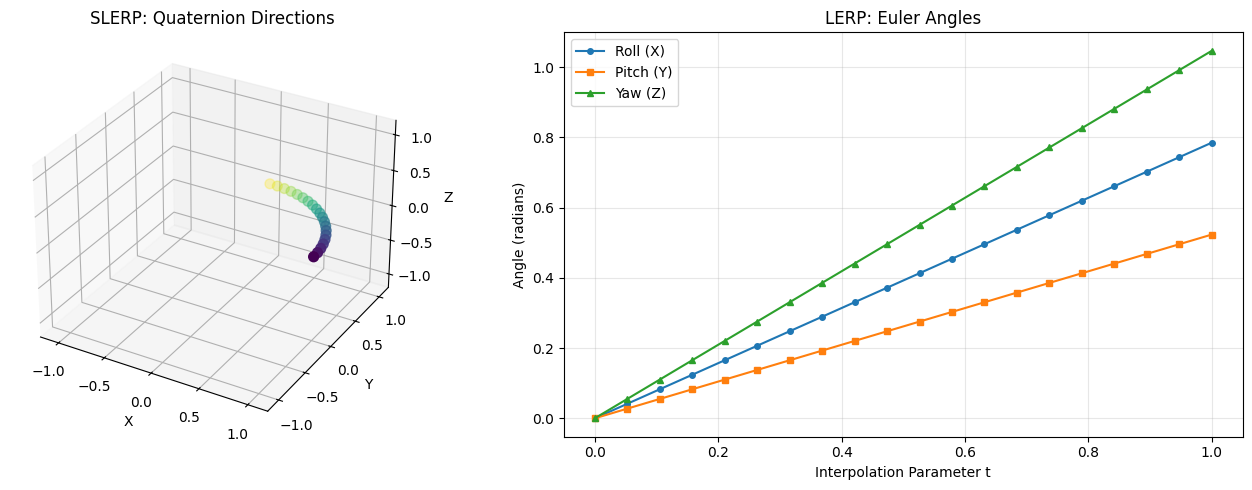

In [ ]:
# experiment :D  Visualize the interpolation results 
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 5))

# SLERP visualization
ax1 = fig.add_subplot(121, projection='3d')
q1 = np.array([1.0, 0.0, 0.0, 0.0])
q2 = axis_angle_quaternion("Z", np.pi / 2)
t_values = np.linspace(0, 1, 20)
slerp_dirs = directions_from_quaternions(slerp_quaternion(q1, q2, t_values))

ax1.scatter(slerp_dirs[:, 0], slerp_dirs[:, 1], slerp_dirs[:, 2], c=t_values, cmap='viridis', s=50)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('SLERP: Quaternion Directions')
ax1.set_xlim([-1.2, 1.2])
ax1.set_ylim([-1.2, 1.2])
ax1.set_zlim([-1.2, 1.2])

# LERP visualization
ax2 = fig.add_subplot(122)
euler_start = np.array([0.0, 0.0, 0.0])
euler_end = np.array([np.pi/4, np.pi/6, np.pi/3])
t_values = np.linspace(0, 1, 20)
lerp_results = lerp_euler(euler_start, euler_end, t_values)

ax2.plot(t_values, lerp_results[:, 0], 'o-', label='Roll (X)', markersize=4)
ax2.plot(t_values, lerp_results[:, 1], 's-', label='Pitch (Y)', markersize=4)
ax2.plot(t_values, lerp_results[:, 2], '^-', label='Yaw (Z)', markersize=4)
ax2.set_xlabel('Interpolation Parameter t')
ax2.set_ylabel('Angle (radians)')
ax2.set_title('LERP: Euler Angles')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
